# Steam Roguelike Market Analysis

This project analyzes the growth, pricing, popularity, and genre evolution of roguelike games on Steam.

Main questions:
1. How fast are roguelike games growing?
2. What caused the genre explosion after 2017?
3. How are roguelike games priced?
4. Which roguelike subgenres became popular over time?
5. How did Vampire Survivors affect the market?

## Data Cleaning

### Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv("games.csv")

### Clean Release Date

In [2]:
df["Release date"] = pd.to_datetime(
    df["Release date"],
    errors="coerce"
)

df["Year"] = df["Release date"].dt.year

2025 data was excluded because the year is incomplete and would distort yearly trend analysis.

In [3]:
df = df[df["Year"] < 2025]

### Filter Roguelike Games

In [4]:
roguelike_df = df[
    df["Tags"].str.contains(
        "Roguelike|Rogue-lite|Roguelite|Action Roguelike",
        case=False,
        na=False
    )
].copy()

## Roguelike Market Growth

### Roguelike Releases Per Year

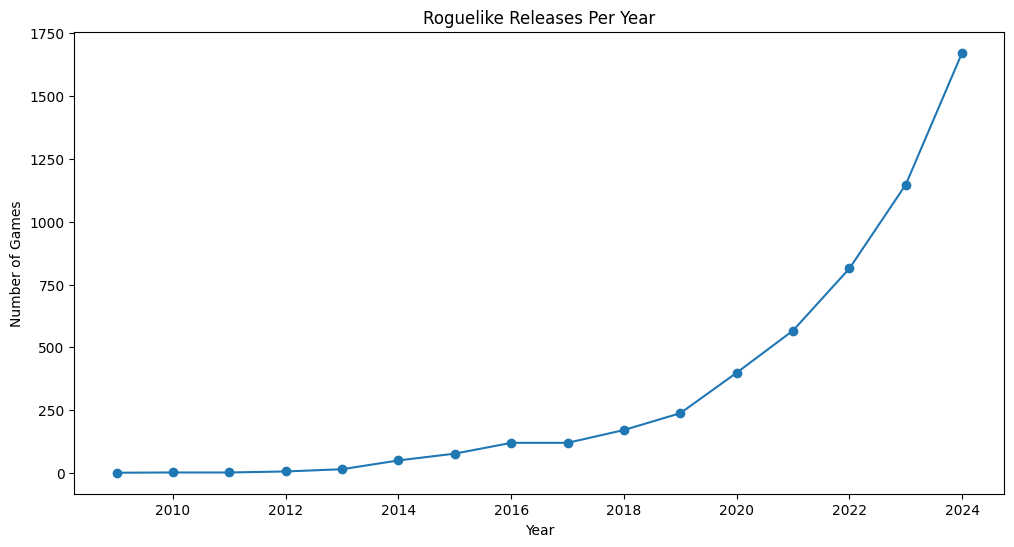

In [5]:
roguelike_yearly = roguelike_df.groupby("Year").size()

plt.figure(figsize=(12,6))

plt.plot(
    roguelike_yearly.index,
    roguelike_yearly.values,
    marker="o"
)

plt.title("Roguelike Releases Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.show()

### Insight

Roguelike releases remained relatively niche before 2017, but the genre entered rapid expansion afterward.

The strongest acceleration occurred after 2020, suggesting that procedural replayability and indie-friendly development pipelines became increasingly attractive in the Steam market.

### Yearly Increase

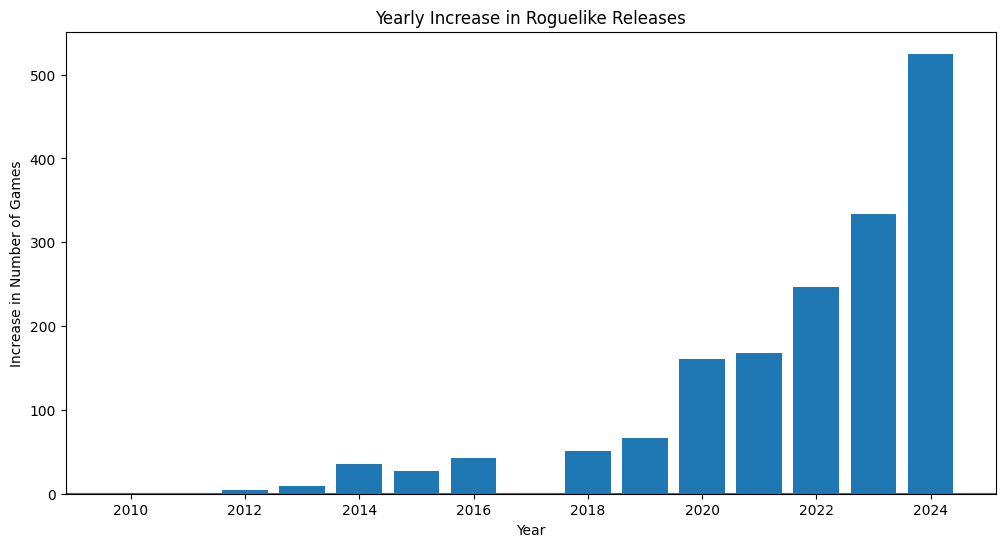

In [6]:
yearly_increase = roguelike_yearly.diff()

plt.figure(figsize=(12,6))

plt.bar(
    yearly_increase.index,
    yearly_increase.values
)

plt.axhline(0)

plt.title("Yearly Increase in Roguelike Releases")
plt.xlabel("Year")
plt.ylabel("Increase in Number of Games")

plt.show()

### Insight

The yearly increase chart shows that growth is not linear.

Instead, roguelike releases accelerated in waves, especially after major breakout titles such as Dead Cells, Slay the Spire, and Vampire Survivors.

### Most Popular Roguelike Games Each Year

In [7]:
top_games = roguelike_df.loc[
    roguelike_df.groupby("Year")["Peak CCU"].idxmax()
]

top_games = top_games[
    ["Year", "Name", "Peak CCU"]
].sort_values("Year")

top_games

,Year,Name,Peak CCU
94106,2009,Zombie Shooter,4
14542,2010,Flotilla,0
28097,2011,The Binding of Isaac,213
46460,2012,Realm of the Mad God Exalt,1853
44030,2013,Tales of Maj'Eyal,131
115665,2014,The Binding of Isaac: Rebirth,14904
92704,2015,Barony,390
118299,2016,Darkest Dungeon®,3848
69838,2017,Bomber Crew,60
96223,2018,Dead Cells,2559


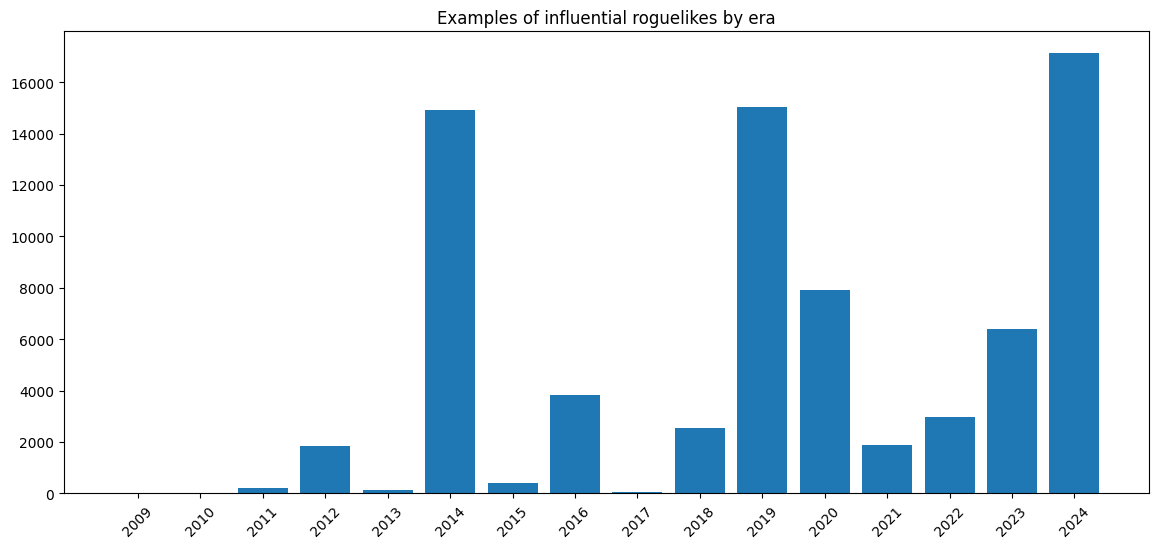

In [8]:
plt.figure(figsize=(14,6))

plt.bar(
    top_games["Year"].astype(str),
    top_games["Peak CCU"]
)

plt.title("Examples of influential roguelikes by era")
plt.xticks(rotation=45)

plt.show()

### Insight

Different eras of roguelikes were defined by different breakout games.

- The Binding of Isaac helped popularize modern indie roguelites
- Slay the Spire expanded the genre into deckbuilding
- Vampire Survivors triggered a wave of low-cost survival roguelikes
- Balatro demonstrated the growing popularity of hybridized roguelike systems

## Why Did Roguelikes Explode After 2017

### Insight

- Dead Cells popularized polished action roguelites
- Slay the Spire introduced deckbuilding roguelikes to mainstream indie audiences
- Streamer culture favored replayable procedural games
- Lower development cost made roguelikes attractive to indie developers

### Compare Major Subgeneres

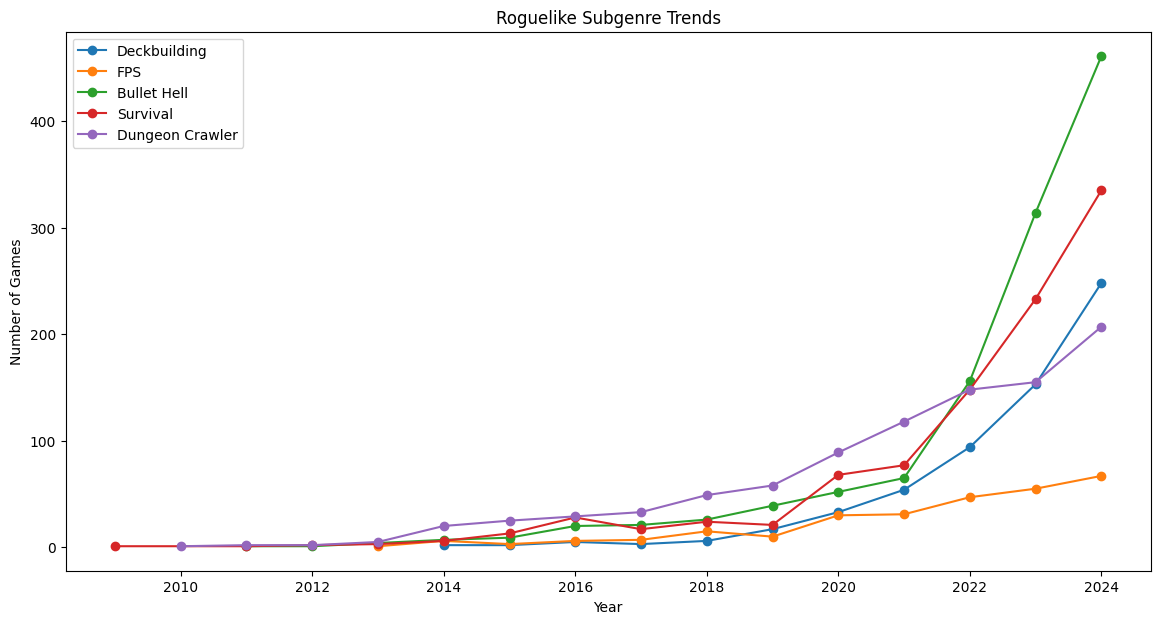

In [9]:
selected_tags = [
    "Deckbuilding",
    "FPS",
    "Bullet Hell",
    "Survival",
    "Dungeon Crawler"
]

plt.figure(figsize=(14,7))

for tag in selected_tags:

    temp_df = roguelike_df[
        roguelike_df["Tags"].str.contains(
            tag,
            case=False,
            na=False
        )
    ]

    yearly = temp_df.groupby("Year").size()

    plt.plot(
        yearly.index,
        yearly.values,
        marker="o",
        label=tag
    )

plt.title("Roguelike Subgenre Trends")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.legend()

plt.show()

### Insight

Bullet Hell and Deckbuilding experienced explosive growth after 2020.

This suggests that the roguelike genre increasingly evolved into hybrid subgenres rather than remaining a pure dungeon-crawling format.

## Pricing Analysis

### Average Roguelike Price

In [10]:
roguelike_df["Price"].mean()

np.float64(5.868974643716454)

### Price Distribution

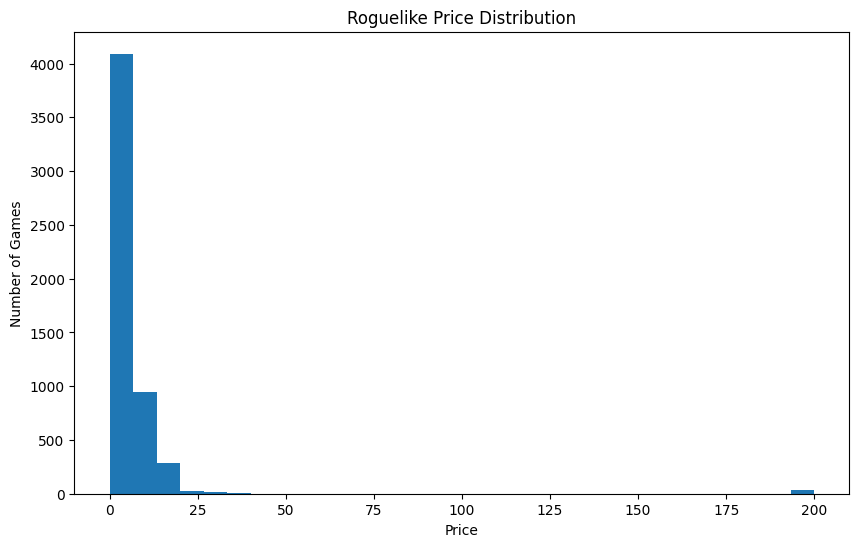

In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    roguelike_df["Price"],
    bins=30
)

plt.title("Roguelike Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Games")

plt.show()

### Insight

Most roguelikes are priced below $10, reinforcing the idea that the genre is heavily driven by indie developers and lower-budget production models.

## Price vs Review Score

### Create Review Ratio

In [12]:
roguelike_df["Review Ratio"] = (
    roguelike_df["Positive"] /
    (
        roguelike_df["Positive"] +
        roguelike_df["Negative"]
    )
)

### Price vs Preview Ratio Scatterplot

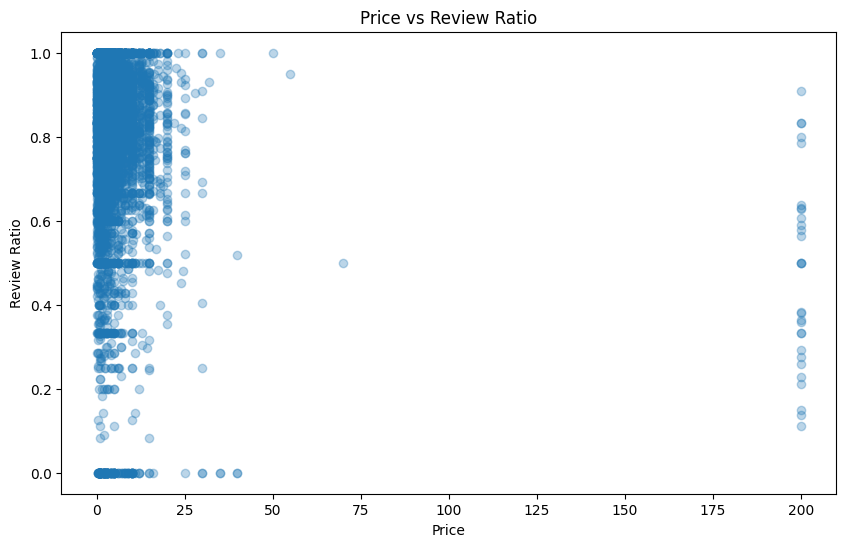

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(
    roguelike_df["Price"],
    roguelike_df["Review Ratio"],
    alpha=0.3
)

plt.title("Price vs Review Ratio")
plt.xlabel("Price")
plt.ylabel("Review Ratio")

plt.show()

### Insight

Lower-priced roguelikes generally maintain strong review ratios.

This may indicate that players are more tolerant of experimental or smaller-scale games when the price barrier is low.

## Post-2017 Price Range Analysis

### Create Price Ranges

In [14]:
bins = [0, 5, 10, 20, 40, 100]

labels = [
    "$0-5",
    "$5-10",
    "$10-20",
    "$20-40",
    "$40+"
]

roguelike_df["Price Range"] = pd.cut(
    roguelike_df["Price"],
    bins=bins,
    labels=labels
)

### Filter Post-2017

In [15]:
post_2017 = roguelike_df[
    roguelike_df["Year"] >= 2017
]

### Average Review Ratio by Price Range and Year

In [16]:
grouped = post_2017.groupby(
    ["Year", "Price Range"]
)["Review Ratio"].mean().unstack()

### Plot

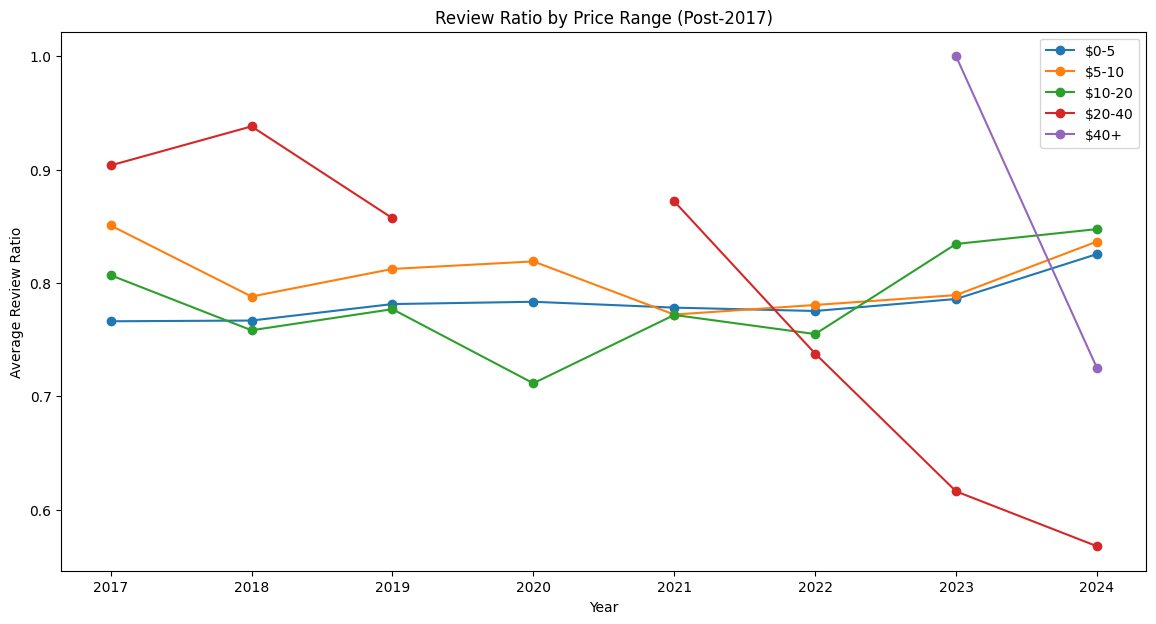

In [17]:
plt.figure(figsize=(14,7))

for column in grouped.columns:

    plt.plot(
        grouped.index,
        grouped[column],
        marker="o",
        label=column
    )

plt.title("Review Ratio by Price Range (Post-2017)")
plt.xlabel("Year")
plt.ylabel("Average Review Ratio")

plt.legend()

plt.show()

### Insight

Since 2017, lower and mid-priced roguelikes consistently achieved stable review performance.

Higher-priced roguelikes showed more volatile reception, suggesting increased player expectations at premium price points.

## Roguelike Tag Co-ocurrence

### Extract Tags

In [18]:
tag_counter = Counter()

for tags in roguelike_df["Tags"].dropna():

    for tag in tags.split(","):

        tag = tag.strip()

        if tag.lower() not in [
            "roguelike",
            "rogue-lite",
            "roguelite"
        ]:

            tag_counter[tag] += 1

### Most Common Roguelike Tags

In [19]:
top_tags = pd.DataFrame(
    tag_counter.items(),
    columns=["Tag", "Count"]
).sort_values(
    "Count",
    ascending=False
).head(25)

### Plot

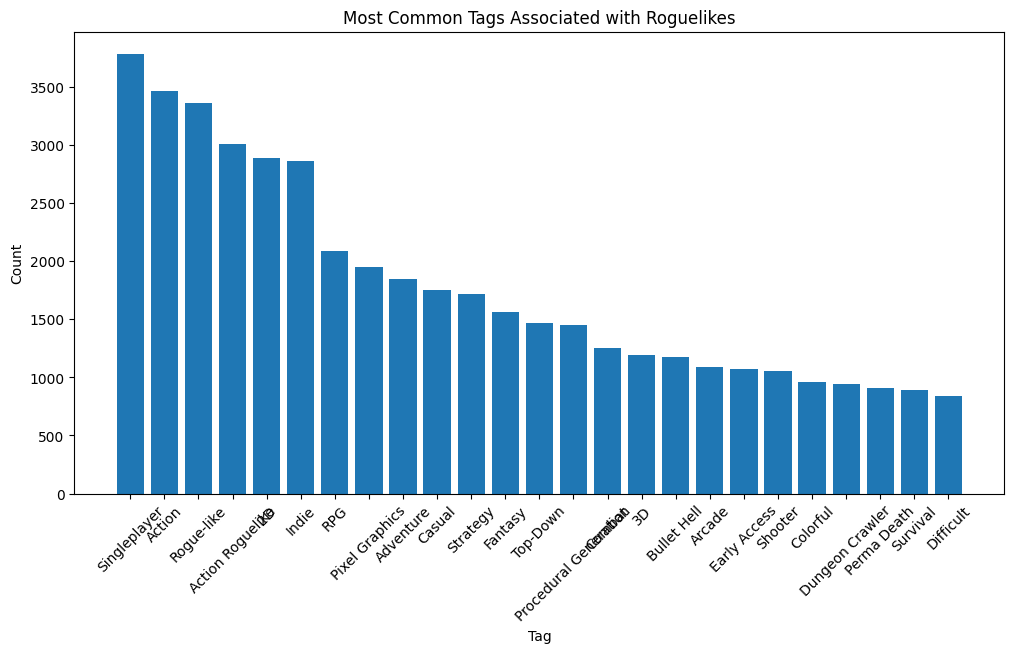

In [20]:
plt.figure(figsize=(12,6))

plt.bar(
    top_tags["Tag"],
    top_tags["Count"]
)

plt.xticks(rotation=45)

plt.title("Most Common Tags Associated with Roguelikes")
plt.xlabel("Tag")
plt.ylabel("Count")

plt.show()

### Insight

Roguelikes are strongly associated with action, replayability, procedural generation, and indie-focused design.

The prevalence of tags such as Bullet Hell and Deckbuilding also highlights the genre's increasing hybridization over time.

## Yearly Subgenre Evolution

### FPS Roguelikes by Year

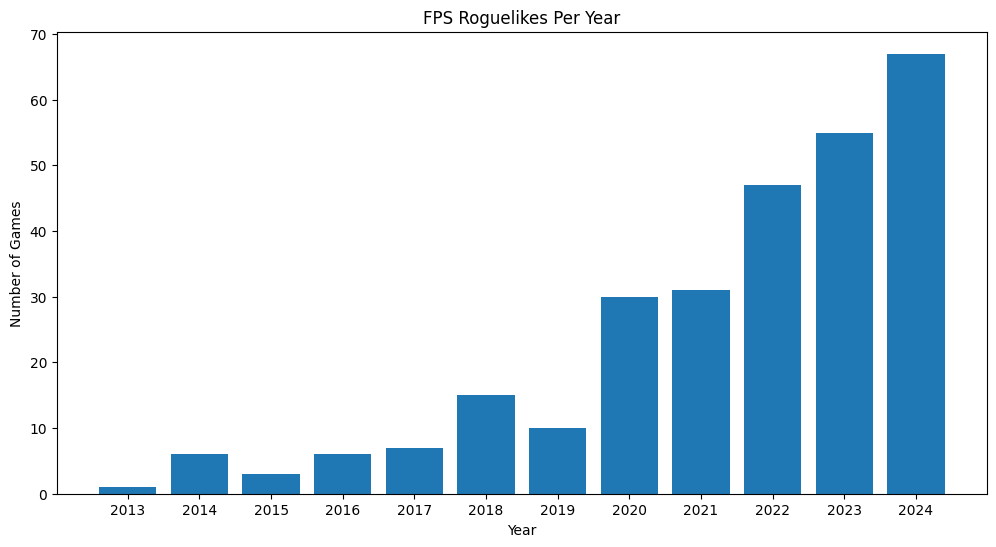

In [21]:
deckbuilder_df = roguelike_df[
    roguelike_df["Tags"].str.contains(
        "FPS",
        case=False,
        na=False
    )
]

deckbuilder_yearly = deckbuilder_df.groupby("Year").size()

plt.figure(figsize=(12,6))

plt.bar(
    deckbuilder_yearly.index.astype(str),
    deckbuilder_yearly.values
)

plt.title("FPS Roguelikes Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.show()

### Deckbuilding Roguelikes by Year

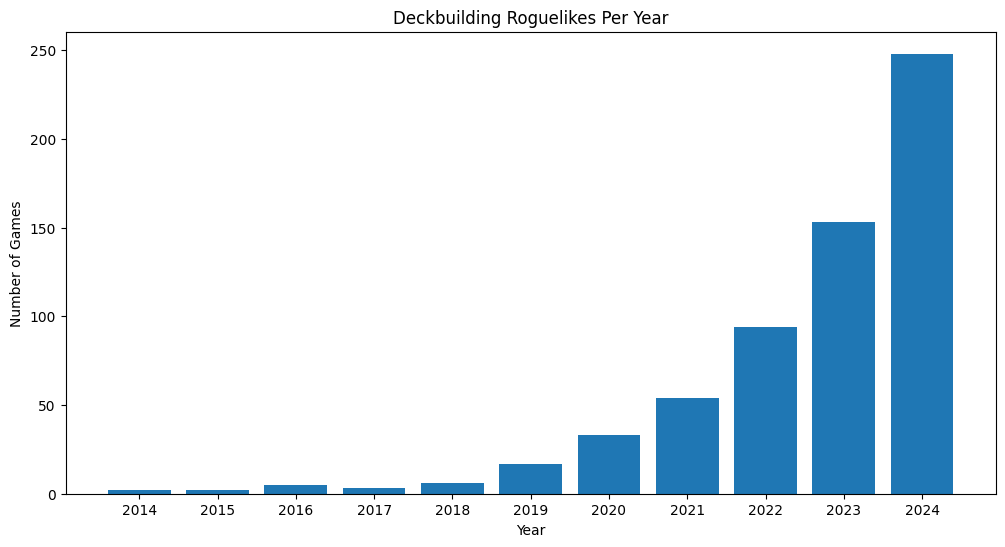

In [22]:
deckbuilder_df = roguelike_df[
    roguelike_df["Tags"].str.contains(
        "Deckbuilding",
        case=False,
        na=False
    )
]

deckbuilder_yearly = deckbuilder_df.groupby("Year").size()

plt.figure(figsize=(12,6))

plt.bar(
    deckbuilder_yearly.index.astype(str),
    deckbuilder_yearly.values
)

plt.title("Deckbuilding Roguelikes Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.show()

# Final Conclusion

## Key Findings

- Roguelike releases accelerated significantly after 2017
- Deckbuilding and bullet hell became major roguelike hybrid genres
- Lower-priced roguelikes maintained strong review ratios
- The genre became increasingly diversified after Vampire Survivors

## Conclusion

This analysis suggests that roguelike games became one of the fastest-growing indie genres on Steam after 2017.

Possible reasons include:
- Lower development cost
- High replayability
- Streamer-friendly gameplay
- The success of influential titles such as Slay the Spire, Hades, and Vampire Survivors

The genre also became increasingly diversified, expanding into:
- Deckbuilding
- FPS
- Bullet Hell
- Survival hybrids

Price analysis suggests that lower-priced roguelikes often maintain strong review scores, potentially because players value replayability and content efficiency more than production scale.